<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### Выполнил Мерочкин Илья

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [13]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt


from sklearn.metrics import accuracy_score, roc_auc_score

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [ ]:
from google.colab import drive # Если вы работаете в коллабе
drive.mount('/content/drive')

Mounted at /content/drive


# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [8]:
import numpy as np
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """

        features_num = X.shape[0]
        stoped_with_tolerance = False

        if self.w0 is None:
            self.w0 = np.zeros(X.shape[1])
        self.w = self.w0.copy()

        for i in range(self.max_iter):
            loss = self.calc_loss(X, y)
            self.loss_history.append(loss)

            if self.gd_type == 'full':
                grad = self.calc_gradient(X, y)
            else:
                rand_elem = np.random.randint(0, features_num)
                grad = self.calc_gradient(X[rand_elem:rand_elem + 1], y[rand_elem:rand_elem + 1])
            
            new_w = self.w - self.eta * grad

            if np.linalg.norm(new_w - self.w) < self.tolerance:
                stoped_with_tolerance = True
                break
            self.w = new_w

        if not stoped_with_tolerance:
            self.loss_history.append( self.calc_loss(X, y))

        return self

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        return self.sigmoid(X @ self.w)


    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        
        return (self.predict_proba(X) >= 0.5).astype(int)

    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        # В качестве лосса тут рассматриваем LogLoss !

        return (1 / X.shape[0]) * X.T @ (self.sigmoid(X @ self.w) - y)


    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        
        pred = self.sigmoid(X @ self.w)
        return -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))


Теперь проверим работу вашего класса на синтетических данных.

In [9]:
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [10]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


,gd_type,'full'
,tolerance,0.0001
,max_iter,1000
,w0,"array([0., 0.... 0., 0., 0.])"
,eta,0.01


ROC-AUC score for custom lr-stohastic: 0.8640789100013875, accuracy: 0.8640666666666666
ROC-AUC score for custom lr-full: 0.8660576072055748, accuracy: 0.8660333333333333
ROC-AUC score for sklearn lr: 0.8681011072682042, accuracy: 0.8681


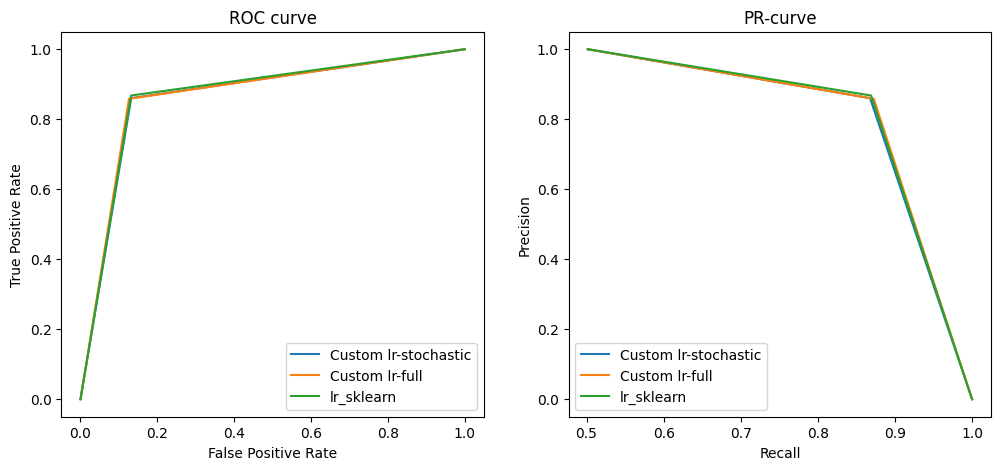

In [39]:
from sklearn.linear_model import LogisticRegression


lr_sklearn = LogisticRegression(random_state=42, max_iter=1000)
lr_sklearn.fit(X_train, y_train)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

y_pred_sgd = lr_sgd.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred_sgd)
auc = roc_auc_score(y_test, y_pred_sgd)
plt.plot(fpr, tpr, label='Custom lr-stochastic')
print(f"ROC-AUC score for custom lr-stohastic: {roc_auc_score(y_test, y_pred_sgd)}, accuracy: {accuracy_score(y_test, y_pred_sgd)}")

y_pred_full = lr_full.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred_full)
plt.plot(fpr, tpr, label='Custom lr-full')
print(f"ROC-AUC score for custom lr-full: {roc_auc_score(y_test, y_pred_full)}, accuracy: {accuracy_score(y_test, y_pred_full)}")

y_pred_lr = lr_sklearn.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred_lr)
plt.plot(fpr, tpr, label='lr_sklearn')
print(f"ROC-AUC score for sklearn lr: {roc_auc_score(y_test, y_pred_lr)}, accuracy: {accuracy_score(y_test, y_pred_lr)}")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()


plt.subplot(1, 2, 2)
precision, recall, _ = precision_recall_curve(y_test, y_pred_sgd)
plt.plot(precision, recall, label='Custom lr-stochastic')

precision, recall, _ = precision_recall_curve(y_test, y_pred_full)
plt.plot(precision, recall, label='Custom lr-full')

precision, recall, _ = precision_recall_curve(y_test, y_pred_lr)
plt.plot(precision, recall, label='lr_sklearn')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-curve')
plt.legend()
plt.show()

- Качество. Все три модели показали высокий результат roc-auc, однако ненамного, но модель из библиотеки показала результат лучше. Жто можно объяснить наличием L2-регуляризации, а также метод оптимизации по умолчанию `lbfgs`.
- Отличия. Как сказано в прошлом пункте, наличие L2-регуляризации, а также оптимизации по умолчанию `lbfgs`.

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

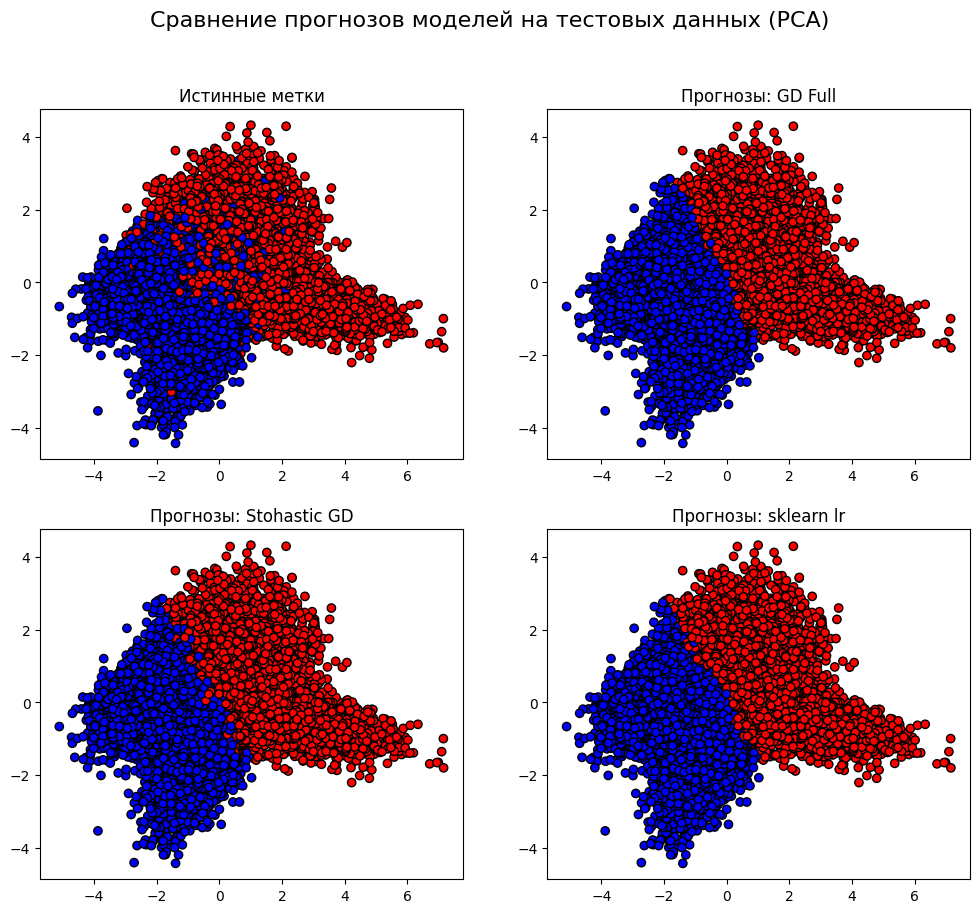

In [40]:
y_pred_full = lr_full.predict(X_test)
y_pred_sgd = lr_sgd.predict(X_test)
y_pred_sklearn = lr_sklearn.predict(X_test)

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Сравнение прогнозов моделей на тестовых данных (PCA)', fontsize=16)

axes[0, 0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='bwr', edgecolors='k')
axes[0, 0].set_title('Истинные метки')

axes[0, 1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_full, cmap='bwr', edgecolors='k')
axes[0, 1].set_title('Прогнозы: GD Full')

axes[1, 0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_sgd, cmap='bwr', edgecolors='k')
axes[1, 0].set_title('Прогнозы: Stohastic GD')

axes[1, 1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_sklearn, cmap='bwr', edgecolors='k')
axes[1, 1].set_title('Прогнозы: sklearn lr')

plt.show()

Как видим, графики самх моделей между собой не особо различаются. Однако они отличаются от графика с истинными метками - выбросы перекрашены в классы, к которым они ближе.

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [34]:
from sklearn.model_selection import train_test_split

PATH = './train.csv'
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [42]:
print(f"Количество пропусков: {data.isna().sum().sum()}")
data.info()

Количество пропусков: 2594
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [44]:
data = data.fillna('')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7613 non-null   object
 2   location  7613 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [46]:
data.nunique()

id          7613
keyword      222
location    3342
text        7503
target         2
dtype: int64

- Количество уникальных значений id очень высокое, следовательно для нашей модели будет абсолютно бесполезным
- target - целевая переменная, следовательно имеем дело с бинарной классификацией
- keyword - невысокая кардинальность, следовательно переменная может быть полезной
- location - высокая кардинальность, нужно аккуратно обработать данную фичу

- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [49]:
data['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

Соотношение классов 57% на 43%, поэтому в качестве метрики возьмем f1-score

- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [50]:
data['concat_text'] = data['keyword'] + ' ' + data['location'] + ' ' + data['text']

- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [51]:
X = data['concat_text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [55]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_vectorized_train = vectorizer.fit_transform(X_train)
X_vectorized_test = vectorizer.transform(X_test)

X_vectorized_train.shape

(5329, 18455)

- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [57]:
from sklearn.metrics import f1_score

lr = LogisticRegression()
lr.fit(X_vectorized_train, y_train)
y_pred = lr.predict(X_vectorized_test)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7529665587918015


- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [58]:
svc = SVC()
svc.fit(X_vectorized_train, y_train)
y_pred = svc.predict(X_vectorized_test)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7430875576036866


Логистическая регрессия справилась с данной задачей гораздо быстрее, чем SVC - 0.1c против 5.1c. Кроме того, логистическая регрессия показала лучше результат на метрике f1-score.

### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [129]:
vectorizer = CountVectorizer(
            max_features=1300,
            min_df=0.0,
            max_df=0.2
        )
X_vectorized_train = vectorizer.fit_transform(X_train)
X_vectorized_test = vectorizer.transform(X_test)
X_vectorized_train.shape

(5329, 1300)

In [128]:
lr = LogisticRegression()
lr.fit(X_vectorized_train, y_train)
y_pred = lr.predict(X_vectorized_test)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7423442449841605


In [130]:
svc = SVC()
svc.fit(X_vectorized_train, y_train)
y_pred = svc.predict(X_vectorized_test)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7323146576117714


Подобранные параметры:
- min_df = 0
- max_df = 0.2

### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [131]:
X = data[['location', 'keyword', 'text']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [134]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

vectorizer = CountVectorizer(
    max_features=1300,
    min_df=0.0,
    max_df=0.2
)
ohe_location = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
ohe_keyword = OneHotEncoder(sparse_output=True, handle_unknown='ignore')

X_vectorized_text_train = vectorizer.fit_transform(X_train['text'])
X_vectorized_text_test = vectorizer.transform(X_test['text'])

X_ohe_keyword_train = ohe_location.fit_transform(X_train[['keyword']])
X_ohe_keyword_test = ohe_location.transform(X_test[['keyword']])

X_ohe_location_train = ohe_keyword.fit_transform(X_train[['location']])
X_ohe_location_test = ohe_keyword.transform(X_test[['location']])

X_train_processed = hstack([X_vectorized_text_train, X_ohe_keyword_train, X_ohe_location_train])
X_test_processed = hstack([X_vectorized_text_test, X_ohe_keyword_test, X_ohe_location_test])

In [135]:
lr = LogisticRegression()
lr.fit(X_train_processed, y_train)
y_pred = lr.predict(X_test_processed)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7420227149810709


In [146]:
svc = SVC(random_state=42)
svc.fit(X_train_processed, y_train)
y_pred = svc.predict(X_test_processed)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7421965317919075


После применения `CountVectorizer` вместе с ohe на логистической регрессии качество немного ухудшилось, а на SVC наоборот улучшилось

### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [141]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'],
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid, 
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_processed, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best F1: {grid.best_score_}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma

Best params: {'C': 1, 'solver': 'saga'}
Best F1: 0.7324776617781901


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [140]:
lr = LogisticRegression(C=1, solver='saga')
lr.fit(X_train_processed, y_train)
y_pred = lr.predict(X_test_processed)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7495995728777363


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Лучшее качество получили при гиперпараметрах:
- C = 1
- solver = saga

При таких гиперпараметрах мы смогли улучшить качество метрики

- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [144]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf', 'poly', 'linear'],
    'gamma': ['scale', 0.01, 0.1, 1],
}

grid = GridSearchCV(
    SVC(),
    param_grid, 
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_processed, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best F1: {grid.best_score_}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best F1: 0.7308010819562605


In [149]:
svc = SVC(C=10, kernel='rbf', gamma=0.01, random_state=42)
svc.fit(X_train_processed, y_train)
y_pred = svc.predict(X_test_processed)
print(f"F1-score: {f1_score(y_test, y_pred)}")

F1-score: 0.7321921590281613


Лучшее качество получилось при параметрах:
- C = 10
- gamma = 0.01
- kernel = rbf

Однако улучшить качество модели не удалось

Ваши выводы здесь.

### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

In [ ]:
# Ваш код здесь

**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤